In [72]:
import pandas as pd

df = pd.read_csv("Crop_recommendation.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [2]:
print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nNumber of unique crops:")
print(df["label"].nunique())

print("\nCrop names:")
print(df["label"].unique())

Number of rows and columns:
(2200, 8)

Column names:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Data types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

Number of unique crops:
22

Crop names:
<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str


# 1. Dataset Description

The Crop Recommendation dataset is used to recommend a suitable crop based on soil and environmental conditions.

The dataset contains 2,200 records and 8 columns. It consists of 7 input features and one target variable.

The input features are Nitrogen (N), Phosphorus (P), Potassium (K), temperature, humidity, soil pH, and rainfall.

The target variable is `label`, which represents the crop to be recommended.

This is a supervised multiclass classification problem because the model learns from labeled data and predicts one crop class from multiple possible crop classes.

## Feature Description

| Feature | Type | Description |
|---|---|---|
| N | Numerical | Nitrogen content in the soil |
| P | Numerical | Phosphorus content in the soil |
| K | Numerical | Potassium content in the soil |
| temperature | Numerical | Temperature of the environment |
| humidity | Numerical | Humidity level |
| ph | Numerical | Soil pH value |
| rainfall | Numerical | Amount of rainfall |
| label | Categorical | Crop class to be predicted |

In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [4]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [5]:
df = df.drop_duplicates()

print("Dataset shape after duplicate removal:", df.shape)

Dataset shape after duplicate removal: (2200, 8)


In [6]:
print("Number of samples in each crop class:")
print(df["label"].value_counts().sort_index())

Number of samples in each crop class:
label
apple          100
banana         100
blackgram      100
chickpea       100
coconut        100
coffee         100
cotton         100
grapes         100
jute           100
kidneybeans    100
lentil         100
maize          100
mango          100
mothbeans      100
mungbean       100
muskmelon      100
orange         100
papaya         100
pigeonpeas     100
pomegranate    100
rice           100
watermelon     100
Name: count, dtype: int64


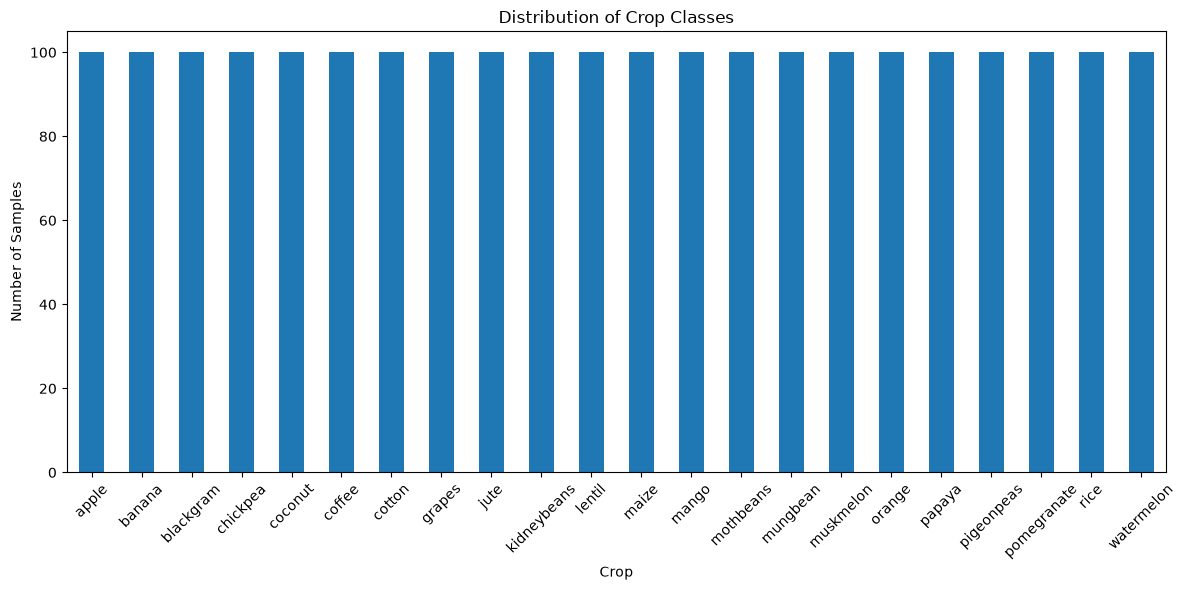

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df["label"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Crop Classes")
plt.xlabel("Crop")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [9]:
print("Data types of all columns:")
print(df.dtypes)


Data types of all columns:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object


In [10]:
print("Minimum values:")
print(df.drop("label", axis=1).min())

print("\nMaximum values:")
print(df.drop("label", axis=1).max())

Minimum values:
N               0.000000
P               5.000000
K               5.000000
temperature     8.825675
humidity       14.258040
ph              3.504752
rainfall       20.211267
dtype: float64

Maximum values:
N              140.000000
P              145.000000
K              205.000000
temperature     43.675493
humidity        99.981876
ph               9.935091
rainfall       298.560117
dtype: float64


# 2. Data Preprocessing

The dataset was checked before model training to ensure that the data is clean and suitable for machine learning.

The following preprocessing checks were performed:

- Missing values were checked in all columns.
- Duplicate records were checked and removed if present.
- The input features are numerical, so no categorical encoding is required for the input variables.
- The target variable `label` is categorical and will be encoded before model training.
- Feature scaling will be applied where required using the training data only.
- The data will be split into training and testing sets before fitting preprocessing transformations to prevent data leakage.

In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label_encoded"] = label_encoder.fit_transform(df["label"])

print("Target encoding completed successfully!")
print("\nCrop-to-number mapping:")

for crop, number in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(crop, "->", number)

Target encoding completed successfully!

Crop-to-number mapping:
apple -> 0
banana -> 1
blackgram -> 2
chickpea -> 3
coconut -> 4
coffee -> 5
cotton -> 6
grapes -> 7
jute -> 8
kidneybeans -> 9
lentil -> 10
maize -> 11
mango -> 12
mothbeans -> 13
mungbean -> 14
muskmelon -> 15
orange -> 16
papaya -> 17
pigeonpeas -> 18
pomegranate -> 19
rice -> 20
watermelon -> 21


In [12]:
# Define input features
X = df[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]]

# Define target variable
y = df["label_encoded"]

print("Input features (X):")
print(X.columns.tolist())

print("\nTarget variable (y):")
print(y.name)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Input features (X):
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

Target variable (y):
label_encoded

Shape of X: (2200, 7)
Shape of y: (2200,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (1760, 7)
Testing data shape: (440, 7)

Training target shape: (1760,)
Testing target shape: (440,)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

print("\nScaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

print("\nMean of first feature in scaled training data:",
      X_train_scaled[:, 0].mean())

print("Standard deviation of first feature in scaled training data:",
      X_train_scaled[:, 0].std())

Feature scaling completed successfully!

Scaled training data shape: (1760, 7)
Scaled testing data shape: (440, 7)

Mean of first feature in scaled training data: 2.826022244500398e-17
Standard deviation of first feature in scaled training data: 1.0


In [15]:
print("Data Leakage Check")
print("------------------")

print("Scaler was fitted using X_train only.")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining data mean after scaling:")
print(X_train_scaled.mean(axis=0))

print("\nTraining data standard deviation after scaling:")
print(X_train_scaled.std(axis=0))

Data Leakage Check
------------------
Scaler was fitted using X_train only.
Training samples: 1760
Testing samples: 440

Training data mean after scaling:
[ 2.82602224e-17  8.07434927e-17  5.55111512e-17 -2.84620812e-16
 -1.46347581e-16 -4.72349432e-16  2.22044605e-16]

Training data standard deviation after scaling:
[1. 1. 1. 1. 1. 1. 1.]


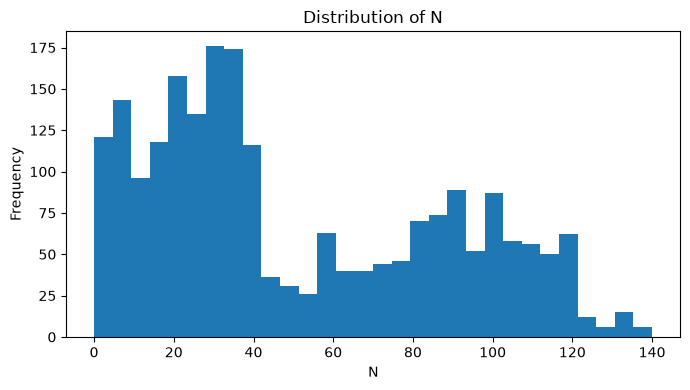

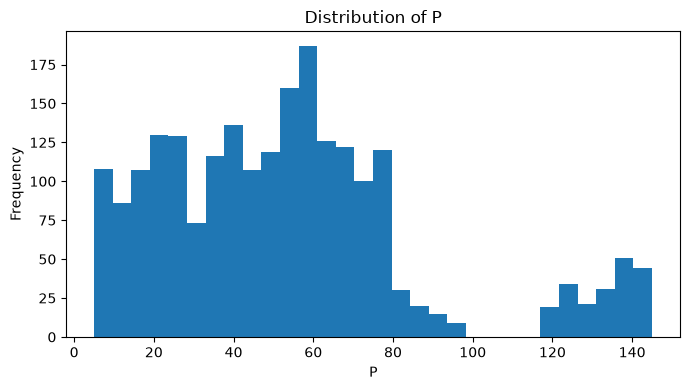

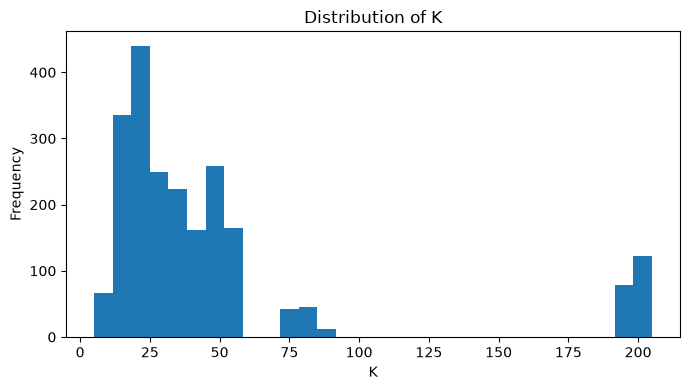

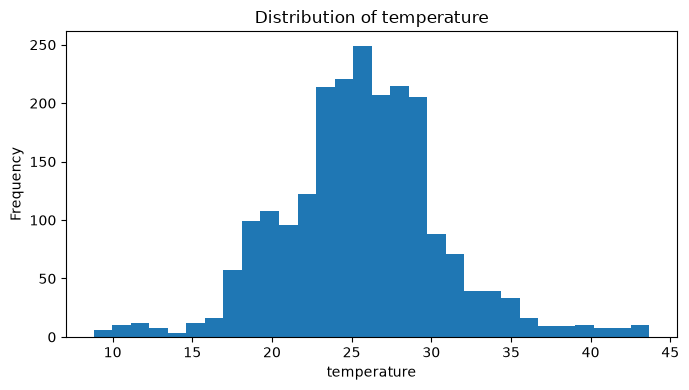

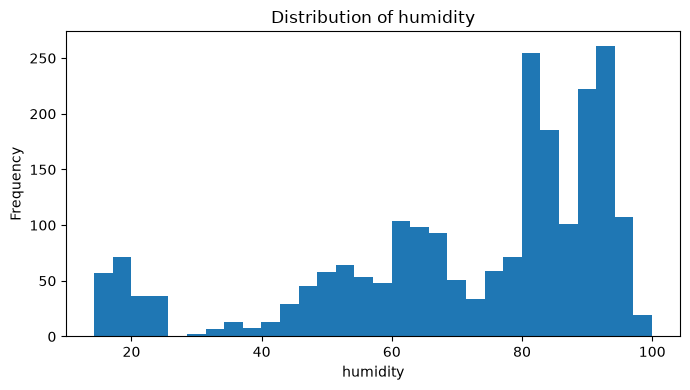

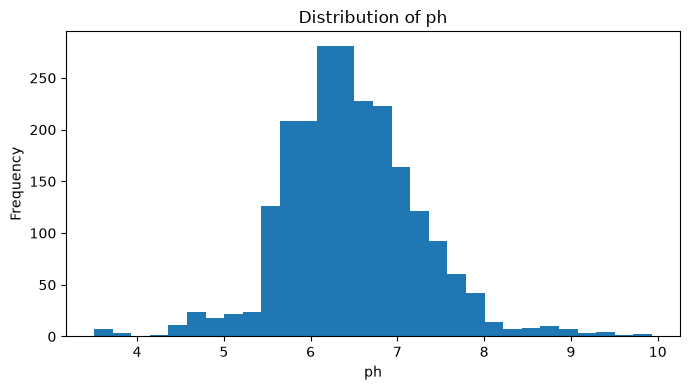

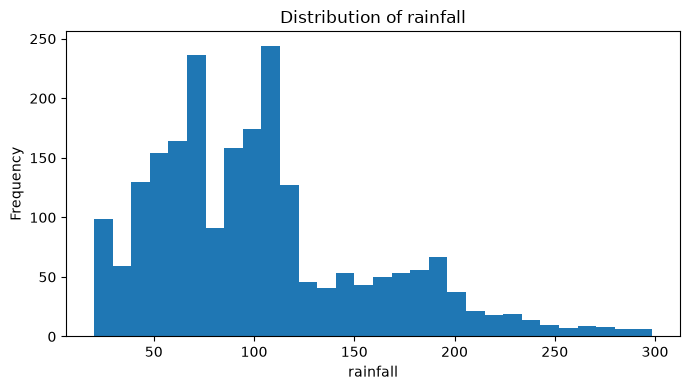

In [16]:
import matplotlib.pyplot as plt

features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

for feature in features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[feature], bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

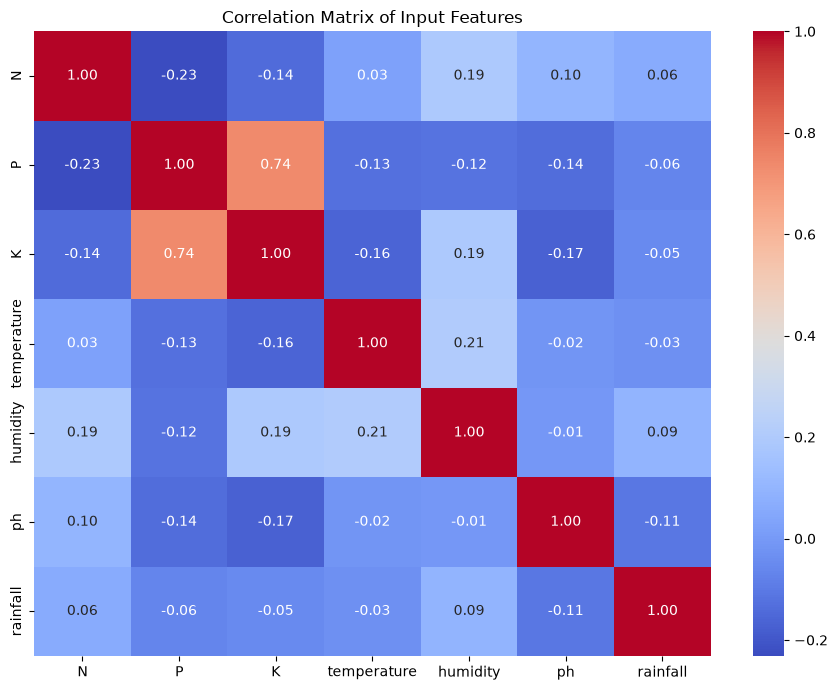

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df[features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Input Features")
plt.tight_layout()
plt.show()

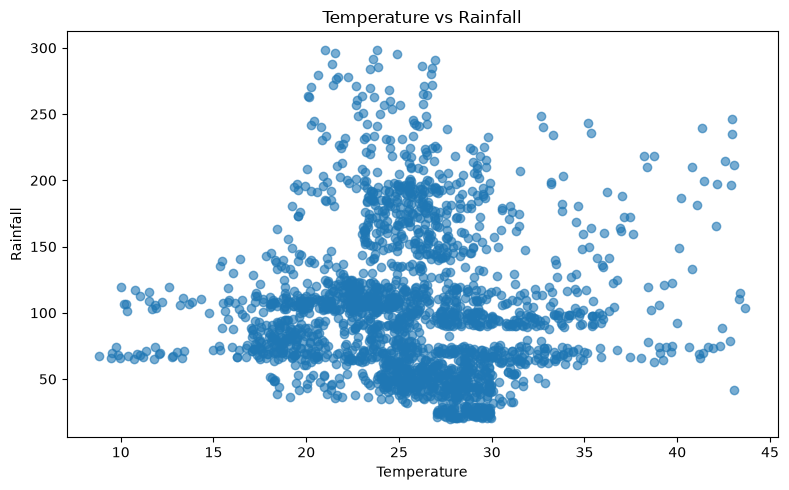

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["temperature"],
    df["rainfall"],
    alpha=0.6
)

plt.title("Temperature vs Rainfall")
plt.xlabel("Temperature")
plt.ylabel("Rainfall")

plt.tight_layout()
plt.show()

In [19]:
class_distribution = df["label"].value_counts().sort_index()

class_percentage = (
    df["label"].value_counts(normalize=True).sort_index() * 100
)

distribution_table = pd.DataFrame({
    "Number of Samples": class_distribution,
    "Percentage": class_percentage.round(2)
})

print("Crop Class Distribution:")
distribution_table

Crop Class Distribution:


,Number of Samples,Percentage
label,,
apple,100,4.55
banana,100,4.55
blackgram,100,4.55
chickpea,100,4.55
coconut,100,4.55
coffee,100,4.55
cotton,100,4.55
grapes,100,4.55
jute,100,4.55


In [20]:
print("Final dataset shape after preprocessing:")
print(df.shape)

print("\nFinal columns:")
print(df.columns.tolist())

print("\nNumber of input features:", X.shape[1])
print("Number of target classes:", y.nunique())

Final dataset shape after preprocessing:
(2200, 9)

Final columns:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'label_encoded']

Number of input features: 7
Number of target classes: 22


## EDA Observations

The exploratory data analysis produced the following observations:

- The dataset contains 2,200 records and 7 numerical input features.
- The target variable contains 22 different crop classes.
- Each crop class contains 100 samples, indicating a balanced target distribution.
- No missing values were found in the dataset.
- No duplicate records were found.
- The feature distribution plots show the ranges and spread of the numerical variables.
- The correlation matrix was used to identify relationships between the numerical input features.
- The temperature-versus-rainfall scatter plot provides a visual view of the relationship between two environmental variables.

# 3. Feature Engineering and Feature Selection

The original dataset already provides seven meaningful numerical features related to soil and environmental conditions: N, P, K, temperature, humidity, pH, and rainfall.

No additional derived features are introduced at this stage because the available features directly represent the conditions required for crop recommendation.

All seven original input features are retained for model training:

- N
- P
- K
- temperature
- humidity
- ph
- rainfall

The target variable is `label_encoded`.

The feature set is kept unchanged so that the effect of the original agricultural and environmental variables can be evaluated directly by the machine-learning models.

Random Forest Feature Importance:
       Feature  Importance
6     rainfall    0.230184
4     humidity    0.224227
2            K    0.175393
1            P    0.150850
0            N    0.096363
3  temperature    0.072375
5           ph    0.050608


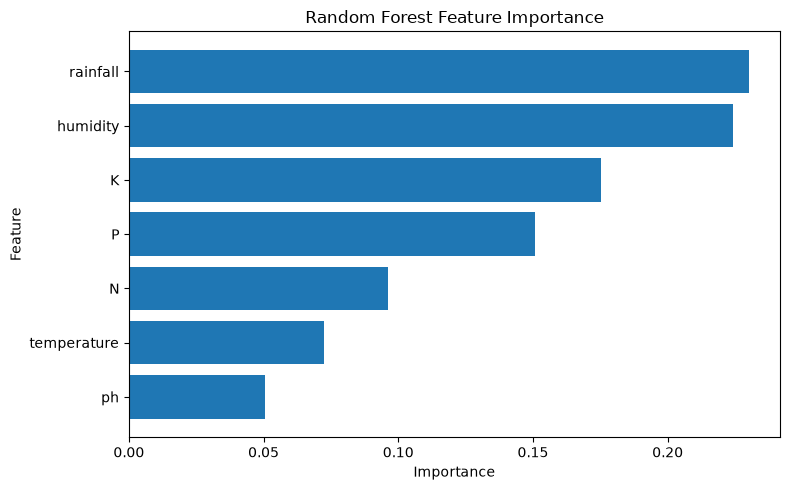

In [21]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_baseline.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_baseline.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Random Forest Feature Importance:")
print(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 4. Model Building and Training

Multiple supervised machine-learning classification algorithms will be trained and evaluated for crop recommendation.

The models selected for comparison are:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting

Standardized features will be used for models that benefit from feature scaling, while tree-based models can work directly with the original numerical features.

The models will be evaluated using the same training and testing data so that their performance can be compared fairly.

In [22]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [23]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [24]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    oob_score=True
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")
print("OOB Score:", random_forest_model.oob_score_)

Random Forest model trained successfully!
OOB Score: 0.9948863636363636


In [25]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [26]:
# Generate predictions for each model

y_pred_logistic = logistic_model.predict(X_test_scaled)

y_pred_tree = decision_tree_model.predict(X_test)

y_pred_rf = random_forest_model.predict(X_test)

y_pred_gb = gradient_boosting_model.predict(X_test)

print("Predictions generated successfully!")

print("\nPrediction shapes:")
print("Logistic Regression:", y_pred_logistic.shape)
print("Decision Tree:", y_pred_tree.shape)
print("Random Forest:", y_pred_rf.shape)
print("Gradient Boosting:", y_pred_gb.shape)

Predictions generated successfully!

Prediction shapes:
Logistic Regression: (440,)
Decision Tree: (440,)
Random Forest: (440,)
Gradient Boosting: (440,)


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

results = []

for model_name, predictions in models_predictions.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, average="weighted"),
        "Recall": recall_score(y_test, predictions, average="weighted"),
        "F1 Score": f1_score(y_test, predictions, average="weighted")
    })

results_df = pd.DataFrame(results)

print("Model Performance Comparison:")
results_df

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.972727,0.974022,0.972727,0.972464
1,Decision Tree,0.963636,0.971784,0.963636,0.963896
2,Random Forest,0.995455,0.995671,0.995455,0.995452
3,Gradient Boosting,0.988636,0.989742,0.988636,0.988723


<Figure size 1000x800 with 0 Axes>

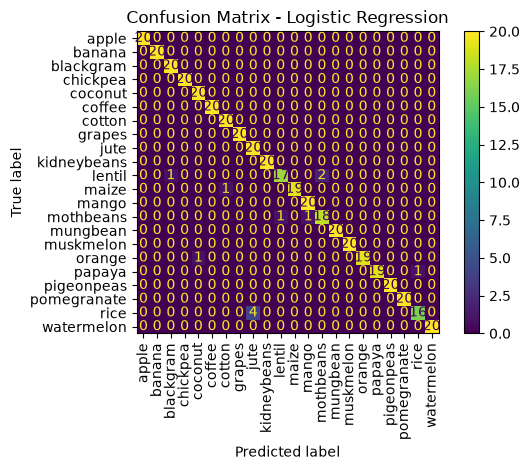

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=label_encoder.classes_
)

disp.plot(
    xticks_rotation=90,
    values_format="d"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

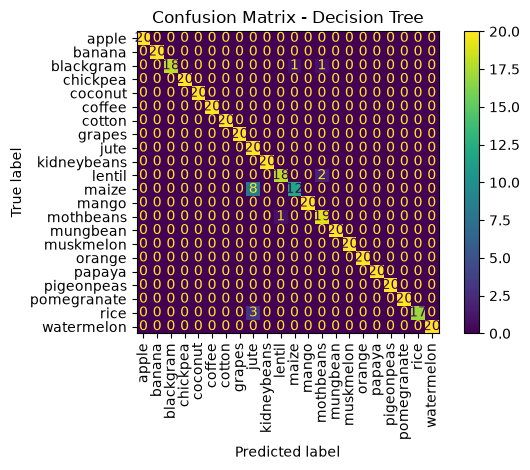

In [29]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=label_encoder.classes_
)

disp.plot(
    xticks_rotation=90,
    values_format="d"
)

plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

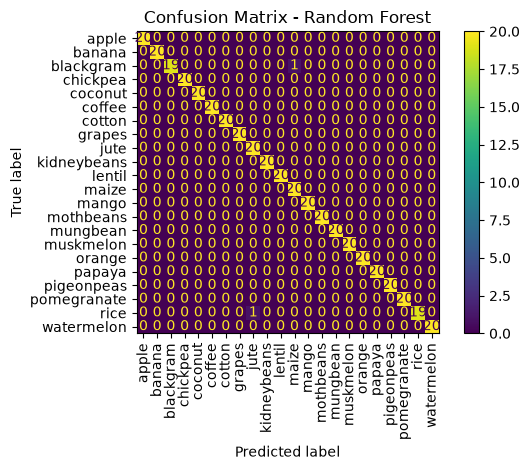

In [30]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=label_encoder.classes_
)

disp.plot(
    xticks_rotation=90,
    values_format="d"
)

plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

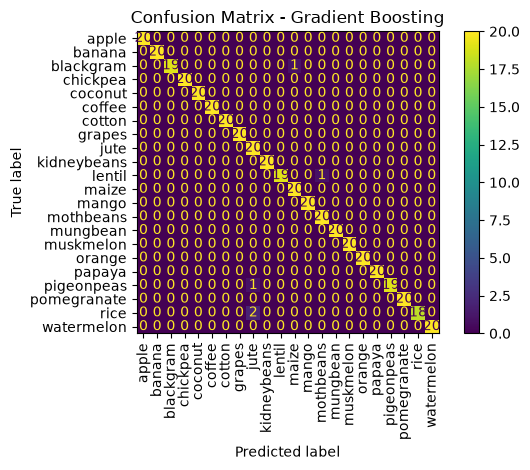

In [31]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=label_encoder.classes_
)

disp.plot(
    xticks_rotation=90,
    values_format="d"
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import classification_report

for model_name, predictions in models_predictions.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=label_encoder.classes_
        )
    )

Logistic Regression
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.95      0.97        20
      p

In [33]:
from sklearn.metrics import roc_auc_score

# Get probability predictions
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)
y_prob_tree = decision_tree_model.predict_proba(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)
y_prob_gb = gradient_boosting_model.predict_proba(X_test)

roc_auc_results = {
    "Logistic Regression": roc_auc_score(
        y_test, y_prob_logistic, multi_class="ovr", average="weighted"
    ),
    "Decision Tree": roc_auc_score(
        y_test, y_prob_tree, multi_class="ovr", average="weighted"
    ),
    "Random Forest": roc_auc_score(
        y_test, y_prob_rf, multi_class="ovr", average="weighted"
    ),
    "Gradient Boosting": roc_auc_score(
        y_test, y_prob_gb, multi_class="ovr", average="weighted"
    )
}

print("Weighted One-vs-Rest ROC-AUC:")
for model_name, score in roc_auc_results.items():
    print(f"{model_name}: {score:.4f}")

Weighted One-vs-Rest ROC-AUC:
Logistic Regression: 0.9998
Decision Tree: 0.9949
Random Forest: 1.0000
Gradient Boosting: 1.0000


In [34]:
results_df["ROC-AUC"] = results_df["Model"].map(roc_auc_results)

results_df = results_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
]

print("Final Model Comparison:")
results_df.round(4)

Final Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9727,0.9740,0.9727,0.9725,0.9998
1,Decision Tree,0.9636,0.9718,0.9636,0.9639,0.9949
2,Random Forest,0.9955,0.9957,0.9955,0.9955,1.0000
3,Gradient Boosting,0.9886,0.9897,0.9886,0.9887,1.0000


In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

cv_results = []

for model_name, model in cv_models.items():

    if model_name == "Logistic Regression":
        scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=cv,
            scoring="accuracy"
        )
    else:
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy"
        )

    cv_results.append({
        "Model": model_name,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

print("5-Fold Stratified Cross-Validation Results:")
cv_results_df.round(4)

5-Fold Stratified Cross-Validation Results:


,Model,CV Mean Accuracy,CV Std
0,Logistic Regression,0.9682,0.0066
1,Decision Tree,0.9750,0.0068
2,Random Forest,0.9943,0.0048
3,Gradient Boosting,0.9869,0.0034


In [36]:
from sklearn.model_selection import GridSearchCV

tree_param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

tree_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=tree_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

tree_grid_search.fit(X_train, y_train)

print("Decision Tree hyperparameter tuning completed!")

print("\nBest parameters:")
print(tree_grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(tree_grid_search.best_score_)

Decision Tree hyperparameter tuning completed!

Best parameters:
{'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5}

Best cross-validation accuracy:
0.9857954545454545


In [37]:
tuned_tree_model = tree_grid_search.best_estimator_

tuned_tree_model.fit(X_train, y_train)

y_pred_tuned_tree = tuned_tree_model.predict(X_test)

tuned_tree_accuracy = accuracy_score(y_test, y_pred_tuned_tree)

baseline_tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Tuning Comparison")
print("--------------------------------")
print("Baseline Accuracy:", round(baseline_tree_accuracy, 4))
print("Tuned Accuracy:", round(tuned_tree_accuracy, 4))
print("Change in Accuracy:", round(
    tuned_tree_accuracy - baseline_tree_accuracy, 4
))

Decision Tree Tuning Comparison
--------------------------------
Baseline Accuracy: 0.9636
Tuned Accuracy: 0.9818
Change in Accuracy: 0.0182


In [38]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

print("Random Forest hyperparameter tuning completed!")

print("\nBest parameters:")
print(rf_grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(rf_grid_search.best_score_)

Random Forest hyperparameter tuning completed!

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best cross-validation accuracy:
0.9960227272727271


In [39]:
tuned_rf_model = rf_grid_search.best_estimator_

tuned_rf_model.fit(X_train, y_train)

y_pred_tuned_rf = tuned_rf_model.predict(X_test)

tuned_rf_accuracy = accuracy_score(y_test, y_pred_tuned_rf)

baseline_rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Tuning Comparison")
print("--------------------------------")
print("Baseline Accuracy:", round(baseline_rf_accuracy, 4))
print("Tuned Accuracy:", round(tuned_rf_accuracy, 4))
print("Change in Accuracy:", round(
    tuned_rf_accuracy - baseline_rf_accuracy, 4
))

Random Forest Tuning Comparison
--------------------------------
Baseline Accuracy: 0.9955
Tuned Accuracy: 0.9955
Change in Accuracy: 0.0


In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

gb_param_grid_fast = {
    "n_estimators": [50, 100],
    "learning_rate": [0.1, 0.2],
    "max_depth": [2, 3]
}

gb_grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid_fast,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid_search.fit(X_train, y_train)

print("Fast Gradient Boosting hyperparameter tuning completed!")

print("\nBest parameters:")
print(gb_grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(round(gb_grid_search.best_score_, 4))

Fast Gradient Boosting hyperparameter tuning completed!

Best parameters:
{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}

Best cross-validation accuracy:
0.9852


In [42]:
tuned_gb_model = gb_grid_search.best_estimator_

tuned_gb_model.fit(X_train, y_train)

y_pred_tuned_gb = tuned_gb_model.predict(X_test)

tuned_gb_accuracy = accuracy_score(y_test, y_pred_tuned_gb)

baseline_gb_accuracy = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Tuning Comparison")
print("-----------------------------------")
print("Baseline Accuracy:", round(baseline_gb_accuracy, 4))
print("Tuned Accuracy:", round(tuned_gb_accuracy, 4))
print("Change in Accuracy:", round(
    tuned_gb_accuracy - baseline_gb_accuracy, 4
))

Gradient Boosting Tuning Comparison
-----------------------------------
Baseline Accuracy: 0.9886
Tuned Accuracy: 0.9932
Change in Accuracy: 0.0045


In [43]:
tuned_results = []

tuned_models_predictions = {
    "Tuned Decision Tree": y_pred_tuned_tree,
    "Tuned Random Forest": y_pred_tuned_rf,
    "Tuned Gradient Boosting": y_pred_tuned_gb
}

for model_name, predictions in tuned_models_predictions.items():
    tuned_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, average="weighted"
        ),
        "Recall": recall_score(
            y_test, predictions, average="weighted"
        ),
        "F1 Score": f1_score(
            y_test, predictions, average="weighted"
        )
    })

tuned_results_df = pd.DataFrame(tuned_results)

print("Tuned Model Performance:")
tuned_results_df.round(4)

Tuned Model Performance:


,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Decision Tree,0.9818,0.9830,0.9818,0.9817
1,Tuned Random Forest,0.9955,0.9957,0.9955,0.9955
2,Tuned Gradient Boosting,0.9932,0.9934,0.9932,0.9932


In [44]:
# Add tuned models to the main comparison table

all_results = results_df.copy()

tuned_comparison = pd.DataFrame({
    "Model": [
        "Tuned Decision Tree",
        "Tuned Random Forest",
        "Tuned Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_tuned_tree),
        accuracy_score(y_test, y_pred_tuned_rf),
        accuracy_score(y_test, y_pred_tuned_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_tuned_tree, average="weighted"),
        precision_score(y_test, y_pred_tuned_rf, average="weighted"),
        precision_score(y_test, y_pred_tuned_gb, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_tuned_tree, average="weighted"),
        recall_score(y_test, y_pred_tuned_rf, average="weighted"),
        recall_score(y_test, y_pred_tuned_gb, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_tuned_tree, average="weighted"),
        f1_score(y_test, y_pred_tuned_rf, average="weighted"),
        f1_score(y_test, y_pred_tuned_gb, average="weighted")
    ]
})

# Calculate ROC-AUC for tuned models
tuned_comparison["ROC-AUC"] = [
    roc_auc_score(
        y_test,
        tuned_tree_model.predict_proba(X_test),
        multi_class="ovr",
        average="weighted"
    ),
    roc_auc_score(
        y_test,
        tuned_rf_model.predict_proba(X_test),
        multi_class="ovr",
        average="weighted"
    ),
    roc_auc_score(
        y_test,
        tuned_gb_model.predict_proba(X_test),
        multi_class="ovr",
        average="weighted"
    )
]

all_results = pd.concat(
    [all_results, tuned_comparison],
    ignore_index=True
)

print("Complete Model Comparison:")
all_results.round(4)

Complete Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9727,0.9740,0.9727,0.9725,0.9998
1,Decision Tree,0.9636,0.9718,0.9636,0.9639,0.9949
2,Random Forest,0.9955,0.9957,0.9955,0.9955,1.0000
3,Gradient Boosting,0.9886,0.9897,0.9886,0.9887,1.0000
4,Tuned Decision Tree,0.9818,0.9830,0.9818,0.9817,0.9905
5,Tuned Random Forest,0.9955,0.9957,0.9955,0.9955,1.0000
6,Tuned Gradient Boosting,0.9932,0.9934,0.9932,0.9932,1.0000


In [45]:
best_model_row = all_results.loc[
    all_results["F1 Score"].idxmax()
]

print("Best-performing model based on F1 Score")
print("----------------------------------------")
print("Model:", best_model_row["Model"])
print("Accuracy:", round(best_model_row["Accuracy"], 4))
print("Precision:", round(best_model_row["Precision"], 4))
print("Recall:", round(best_model_row["Recall"], 4))
print("F1 Score:", round(best_model_row["F1 Score"], 4))
print("ROC-AUC:", round(best_model_row["ROC-AUC"], 4))

Best-performing model based on F1 Score
----------------------------------------
Model: Random Forest
Accuracy: 0.9955
Precision: 0.9957
Recall: 0.9955
F1 Score: 0.9955
ROC-AUC: 1.0


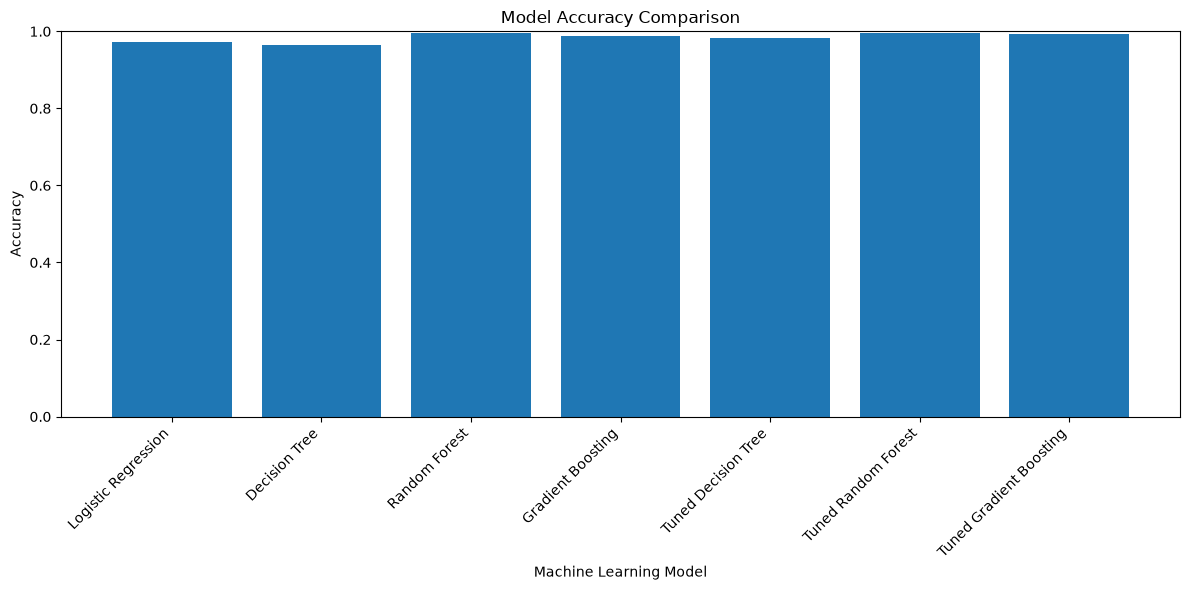

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    all_results["Model"],
    all_results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [47]:
from sklearn.ensemble import VotingClassifier

hybrid_model = VotingClassifier(
    estimators=[
        ("random_forest", tuned_rf_model),
        ("gradient_boosting", tuned_gb_model)
    ],
    voting="soft"
)

hybrid_model.fit(X_train, y_train)

y_pred_hybrid = hybrid_model.predict(X_test)

print("Hybrid Voting Classifier trained successfully!")

print("\nHybrid Model Accuracy:",
      round(accuracy_score(y_test, y_pred_hybrid), 4))

print("Hybrid Model Precision:",
      round(precision_score(
          y_test, y_pred_hybrid, average="weighted"
      ), 4))

print("Hybrid Model Recall:",
      round(recall_score(
          y_test, y_pred_hybrid, average="weighted"
      ), 4))

print("Hybrid Model F1 Score:",
      round(f1_score(
          y_test, y_pred_hybrid, average="weighted"
      ), 4))

Hybrid Voting Classifier trained successfully!

Hybrid Model Accuracy: 0.9955
Hybrid Model Precision: 0.9957
Hybrid Model Recall: 0.9955
Hybrid Model F1 Score: 0.9955


In [48]:
y_prob_hybrid = hybrid_model.predict_proba(X_test)

hybrid_roc_auc = roc_auc_score(
    y_test,
    y_prob_hybrid,
    multi_class="ovr",
    average="weighted"
)

print("Hybrid Model ROC-AUC:",
      round(hybrid_roc_auc, 4))

Hybrid Model ROC-AUC: 1.0


In [49]:
hybrid_row = pd.DataFrame({
    "Model": ["Hybrid Voting Classifier"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_hybrid)
    ],
    "Precision": [
        precision_score(
            y_test, y_pred_hybrid, average="weighted"
        )
    ],
    "Recall": [
        recall_score(
            y_test, y_pred_hybrid, average="weighted"
        )
    ],
    "F1 Score": [
        f1_score(
            y_test, y_pred_hybrid, average="weighted"
        )
    ],
    "ROC-AUC": [
        hybrid_roc_auc
    ]
})

final_results = pd.concat(
    [all_results, hybrid_row],
    ignore_index=True
)

print("Final Model Comparison:")
final_results.round(4)

Final Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9727,0.9740,0.9727,0.9725,0.9998
1,Decision Tree,0.9636,0.9718,0.9636,0.9639,0.9949
2,Random Forest,0.9955,0.9957,0.9955,0.9955,1.0000
3,Gradient Boosting,0.9886,0.9897,0.9886,0.9887,1.0000
4,Tuned Decision Tree,0.9818,0.9830,0.9818,0.9817,0.9905
5,Tuned Random Forest,0.9955,0.9957,0.9955,0.9955,1.0000
6,Tuned Gradient Boosting,0.9932,0.9934,0.9932,0.9932,1.0000
7,Hybrid Voting Classifier,0.9955,0.9957,0.9955,0.9955,1.0000


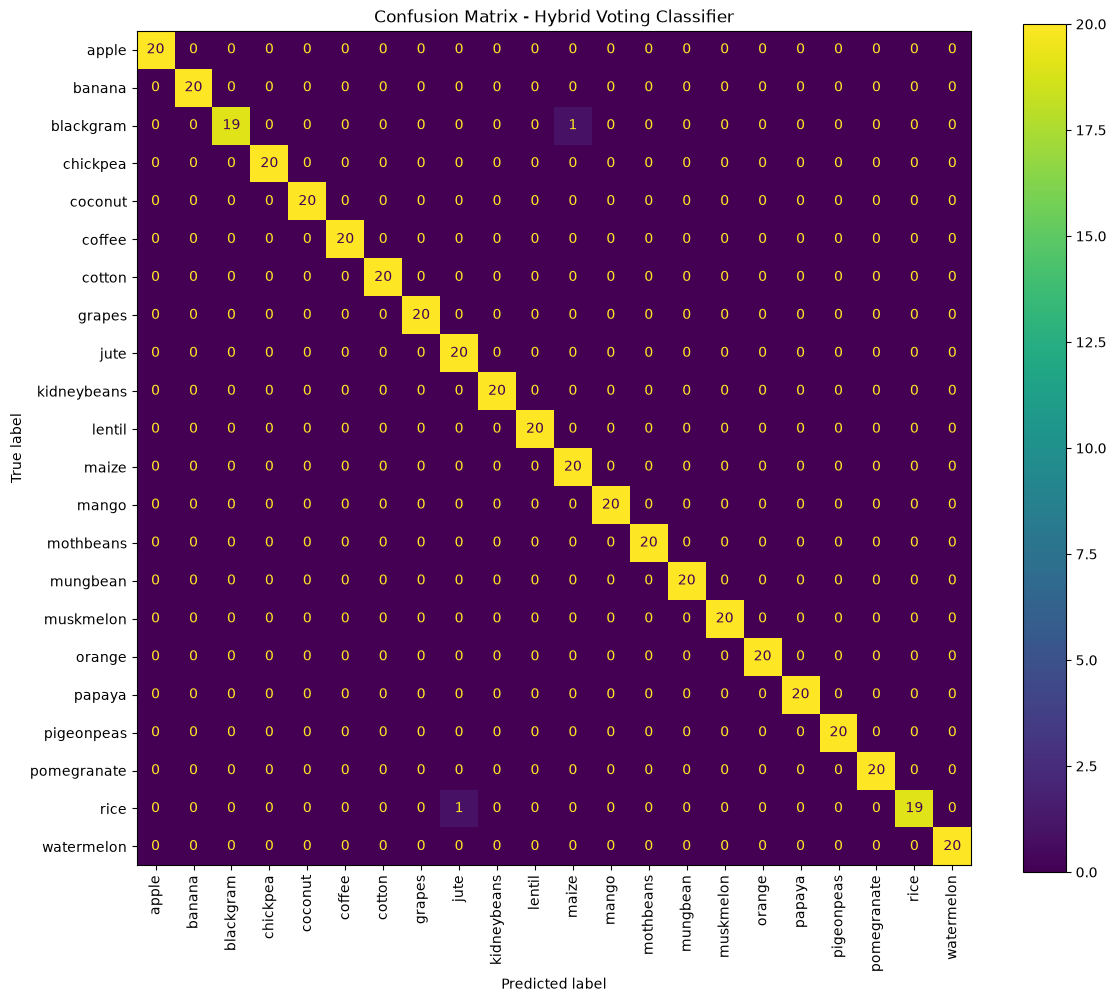

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_hybrid,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

ax.set_title("Confusion Matrix - Hybrid Voting Classifier")

plt.tight_layout()
plt.show()

In [51]:
from sklearn.metrics import classification_report

hybrid_report = classification_report(
    y_test,
    y_pred_hybrid,
    target_names=label_encoder.classes_
)

print("Classification Report - Hybrid Voting Classifier")
print("=" * 60)
print(hybrid_report)

Classification Report - Hybrid Voting Classifier
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.0

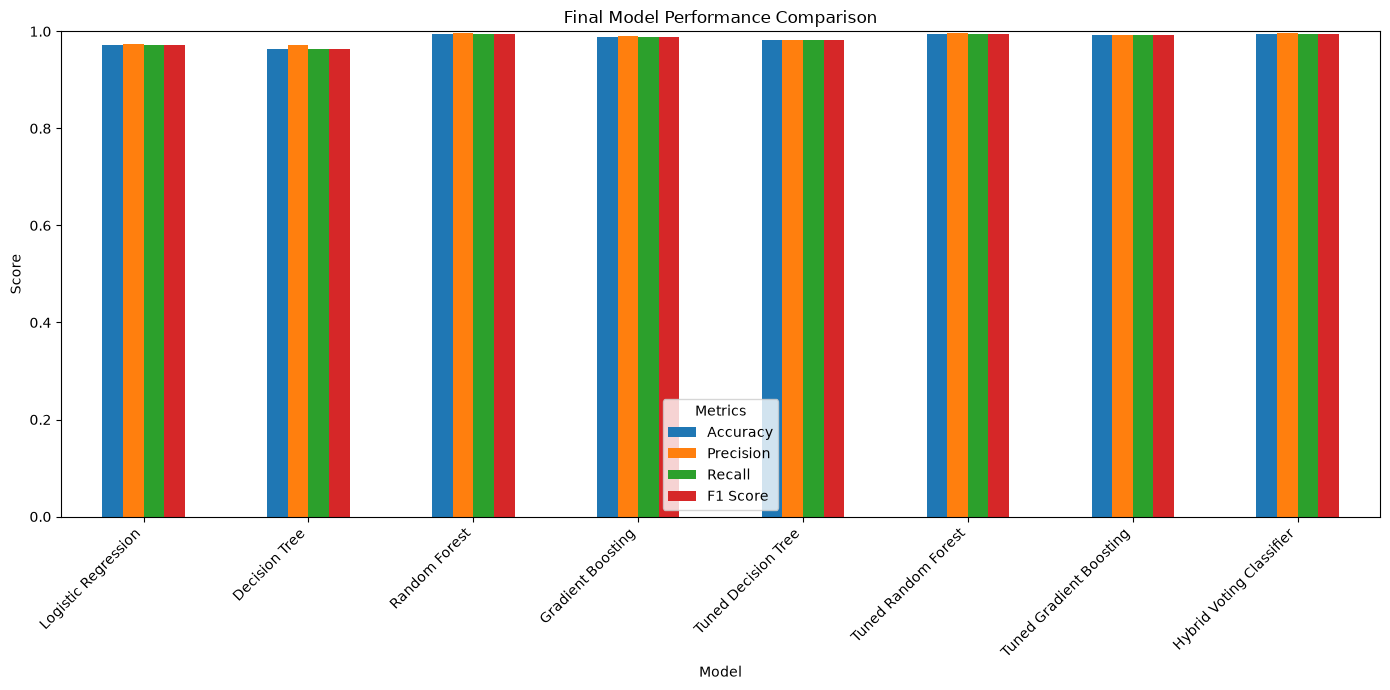

In [52]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

final_results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Final Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=45, ha="right")
plt.legend(title="Metrics")

plt.tight_layout()
plt.show()

Calculating permutation importance...

Permutation Feature Importance:
       Feature  Importance
4     humidity      0.3520
6     rainfall      0.2784
1            P      0.1639
0            N      0.1634
2            K      0.1368
5           ph      0.0057
3  temperature      0.0025


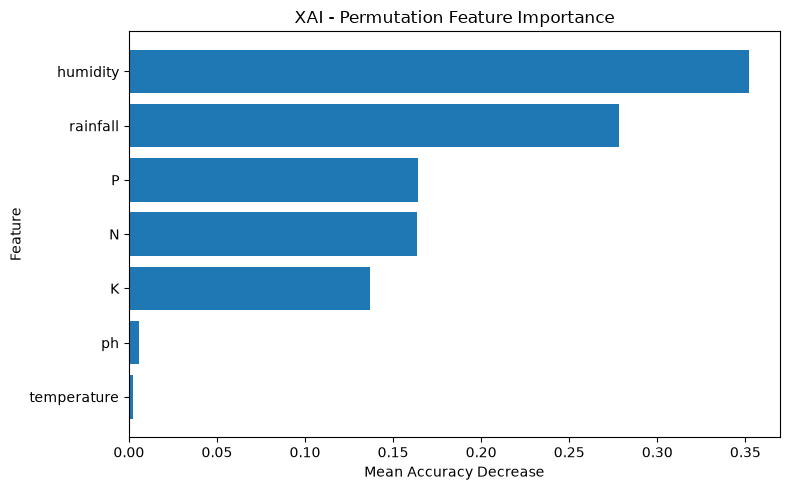

In [53]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

print("Calculating permutation importance...")

perm_result = permutation_importance(
    hybrid_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy",
    n_jobs=-1
)

xai_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_result.importances_mean
}).sort_values(
    by="Importance",
    ascending=False
)

print("\nPermutation Feature Importance:")
print(xai_importance.round(4))

plt.figure(figsize=(8, 5))

plt.barh(
    xai_importance["Feature"],
    xai_importance["Importance"]
)

plt.xlabel("Mean Accuracy Decrease")
plt.ylabel("Feature")
plt.title("XAI - Permutation Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [54]:
import joblib

joblib.dump(hybrid_model, "hybrid_crop_recommendation_model.pkl")

joblib.dump(label_encoder, "crop_label_encoder.pkl")

print("Hybrid model saved successfully!")
print("File: hybrid_crop_recommendation_model.pkl")
print("Label encoder saved successfully!")
print("File: crop_label_encoder.pkl")

Hybrid model saved successfully!
File: hybrid_crop_recommendation_model.pkl
Label encoder saved successfully!
File: crop_label_encoder.pkl


In [55]:
# Sample unseen input
sample_input = pd.DataFrame({
    "N": [90],
    "P": [42],
    "K": [43],
    "temperature": [20.9],
    "humidity": [82.0],
    "ph": [6.5],
    "rainfall": [202.9]
})

# Predict crop
predicted_class = hybrid_model.predict(sample_input)[0]

# Convert numeric prediction back to crop name
predicted_crop = label_encoder.inverse_transform(
    [predicted_class]
)[0]

# Get prediction probabilities
prediction_probabilities = hybrid_model.predict_proba(sample_input)[0]

confidence = prediction_probabilities[predicted_class] * 100

print("Crop Recommendation")
print("-------------------")
print("Predicted Crop:", predicted_crop)
print("Confidence:", round(confidence, 2), "%")

Crop Recommendation
-------------------
Predicted Crop: rice
Confidence: 93.74 %


In [56]:
# Get probabilities for all crop classes
probabilities = hybrid_model.predict_proba(sample_input)[0]

# Get indices of the top 3 predictions
top_3_indices = probabilities.argsort()[-3:][::-1]

print("Top-3 Crop Recommendations")
print("--------------------------")

for rank, index in enumerate(top_3_indices, start=1):
    crop_name = label_encoder.inverse_transform([index])[0]
    probability = probabilities[index] * 100

    print(
        f"{rank}. {crop_name} - {probability:.2f}%"
    )

Top-3 Crop Recommendations
--------------------------
1. rice - 93.74%
2. jute - 4.80%
3. pomegranate - 0.70%


# 5. End-to-End Machine Learning Lifecycle

The proposed crop recommendation system follows an end-to-end machine-learning lifecycle:

**Raw Dataset → Data Cleaning → Preprocessing → Feature Selection → Train/Test Split → Model Training → Hyperparameter Tuning → Model Evaluation → Hybrid Model → Explainable AI → Model Saving → Crop Prediction**

### Lifecycle Explanation

1. **Raw Dataset** – Crop Recommendation dataset containing soil and environmental parameters.
2. **Data Cleaning** – Missing values and duplicate records are checked.
3. **Preprocessing** – The target labels are encoded and numerical features are scaled where required.
4. **Feature Selection** – The seven original input features are retained.
5. **Train/Test Split** – Data is divided into training and testing sets using stratification.
6. **Model Training** – Multiple classification algorithms are trained.
7. **Hyperparameter Tuning** – Selected models are optimized using GridSearchCV.
8. **Model Evaluation** – Accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices are used.
9. **Hybrid Model** – Tuned Random Forest and Gradient Boosting models are combined using soft voting.
10. **Explainable AI** – Permutation feature importance is used to understand feature contribution.
11. **Model Saving** – The trained hybrid model and label encoder are saved as reusable files.
12. **Final Prediction** – New soil and environmental conditions are provided to generate a crop recommendation.

# 6. Results and Discussion

## Model Performance

Multiple supervised classification models were trained for crop recommendation, including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.

Hyperparameter tuning was performed for the Decision Tree, Random Forest, and Gradient Boosting models using GridSearchCV.

The final comparison table presents the performance of the baseline, tuned, and hybrid models using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

## Hybrid Model

A Hybrid Voting Classifier was developed by combining the tuned Random Forest and tuned Gradient Boosting models using soft voting.

The hybrid approach combines the probability predictions of the component models and produces the final crop recommendation.

The hybrid model was evaluated using the same held-out test data used for the other models.

## Explainable AI

Permutation feature importance was used to provide an explanation of how the input features contribute to model performance.

The XAI analysis considers the following seven features:

- Nitrogen (N)
- Phosphorus (P)
- Potassium (K)
- Temperature
- Humidity
- Soil pH
- Rainfall

The resulting feature-importance chart provides a global view of the relative contribution of these features to the hybrid model's predictions.

## Strengths

- Uses multiple machine-learning classification algorithms.
- Compares baseline and tuned models.
- Uses stratified data splitting to preserve class representation.
- Uses multiple classification evaluation metrics.
- Combines tuned models through a hybrid voting approach.
- Includes Explainable AI using permutation feature importance.
- Saves the trained model for reuse in prediction.

## Limitations

- The dataset contains a fixed set of crop classes and may not represent every agricultural environment.
- The prediction quality depends on the quality and representativeness of the training data.
- The current demonstration uses a static dataset and does not yet include real-time agricultural sensor data.
- Further validation with larger and geographically diverse datasets would be required before real-world deployment.

## Objective Achievement

The project demonstrates an end-to-end supervised machine-learning framework for crop recommendation using soil and environmental features.

It includes data preprocessing, exploratory analysis, feature selection, multiple model training, hyperparameter tuning, hybrid modeling, classification evaluation, Explainable AI, model saving, and final crop prediction.

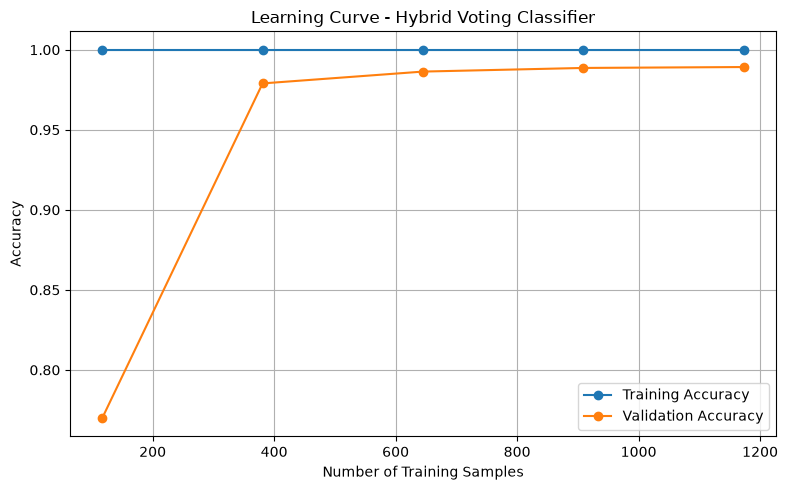

In [57]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, validation_scores = learning_curve(
    hybrid_model,
    X_train,
    y_train,
    cv=3,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.title("Learning Curve - Hybrid Voting Classifier")
plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [70]:
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):

    input_data = pd.DataFrame({
        "N": [N],
        "P": [P],
        "K": [K],
        "temperature": [temperature],
        "humidity": [humidity],
        "ph": [ph],
        "rainfall": [rainfall]
    })

    predicted_class = final_model.predict(input_data)[0]

    predicted_crop = label_encoder.inverse_transform(
        [predicted_class]
    )[0]

    probabilities = final_model.predict_proba(input_data)[0]

    confidence = probabilities[predicted_class] * 100

    return predicted_crop, confidence


# Example prediction
crop, confidence = recommend_crop(
    90,
    42,
    43,
    20.9,
    82.0,
    6.5,
    202.9
)

print("Final Crop Recommendation")
print("-------------------------")
print("Recommended Crop:", crop)
print("Confidence:", round(confidence, 2), "%")

Final Crop Recommendation
-------------------------
Recommended Crop: rice
Confidence: 93.5 %


In [59]:
test_crop, test_confidence = recommend_crop(
    70,      # Nitrogen
    45,      # Phosphorus
    40,      # Potassium
    25.0,    # Temperature
    75.0,    # Humidity
    6.2,     # pH
    180.0    # Rainfall
)

print("Unseen Input Prediction")
print("-----------------------")
print("N:", 70)
print("P:", 45)
print("K:", 40)
print("Temperature:", 25.0)
print("Humidity:", 75.0)
print("pH:", 6.2)
print("Rainfall:", 180.0)

print("\nRecommended Crop:", test_crop)
print("Confidence:", round(test_confidence, 2), "%")

Unseen Input Prediction
-----------------------
N: 70
P: 45
K: 40
Temperature: 25.0
Humidity: 75.0
pH: 6.2
Rainfall: 180.0

Recommended Crop: jute
Confidence: 94.56 %


In [60]:
model_package = {
    "model": hybrid_model,
    "label_encoder": label_encoder,
    "features": [
        "N",
        "P",
        "K",
        "temperature",
        "humidity",
        "ph",
        "rainfall"
    ]
}

joblib.dump(
    model_package,
    "crop_recommendation_model_package.pkl"
)

print("Complete model package saved successfully!")
print("File: crop_recommendation_model_package.pkl")

Complete model package saved successfully!
File: crop_recommendation_model_package.pkl


# M4: K-Means Clustering Analysis

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Use the seven numerical input features
X_cluster = X.copy()

# Test different numbers of clusters
cluster_range = range(2, 11)

inertia_values = []
silhouette_values = []

for k in cluster_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_cluster)

    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(
        silhouette_score(X_cluster, cluster_labels)
    )


# Elbow Method
plt.figure(figsize=(8, 5))

plt.plot(
    list(cluster_range),
    inertia_values,
    marker="o"
)

plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.tight_layout()
plt.show()


# Silhouette Score
plt.figure(figsize=(8, 5))

plt.plot(
    list(cluster_range),
    silhouette_values,
    marker="o"
)

plt.title("K-Means Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()


# Display scores
cluster_results = pd.DataFrame({
    "Number of Clusters": list(cluster_range),
    "Inertia": inertia_values,
    "Silhouette Score": silhouette_values
})

print("K-Means Clustering Results:")
cluster_results.round(4)

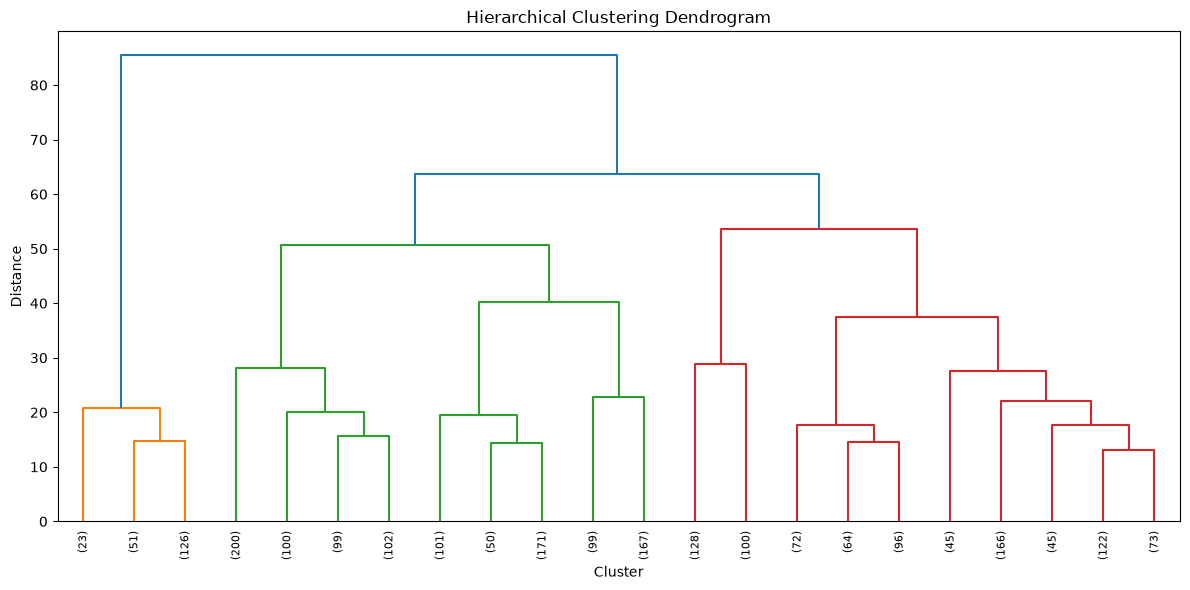

Hierarchical clustering analysis completed successfully!


In [61]:
# M4: Hierarchical Clustering

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Scale the features for clustering
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X)

# Create hierarchical linkage
linked = linkage(
    X_cluster_scaled,
    method="ward"
)

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=22,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

print("Hierarchical clustering analysis completed successfully!")

DBSCAN Clustering Results
-------------------------
Number of clusters: 2
Number of noise points: 0


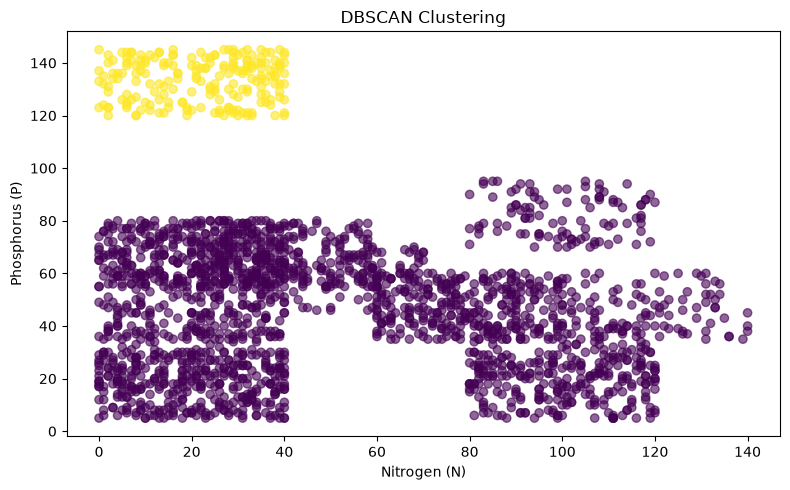

In [62]:
# M4: DBSCAN Clustering

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Scale the features
scaler_dbscan = StandardScaler()
X_dbscan_scaled = scaler_dbscan.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_dbscan_scaled)

# Count clusters and noise points
unique_labels = set(dbscan_labels)

number_of_clusters = len(
    unique_labels - {-1}
)

number_of_noise_points = list(
    dbscan_labels
).count(-1)

print("DBSCAN Clustering Results")
print("-------------------------")
print("Number of clusters:", number_of_clusters)
print("Number of noise points:", number_of_noise_points)

# Visualize using first two features
plt.figure(figsize=(8, 5))

plt.scatter(
    X["N"],
    X["P"],
    c=dbscan_labels,
    alpha=0.6
)

plt.title("DBSCAN Clustering")
plt.xlabel("Nitrogen (N)")
plt.ylabel("Phosphorus (P)")

plt.tight_layout()
plt.show()

Isolation Forest Results
------------------------
Normal records: 2090
Anomalous records: 110


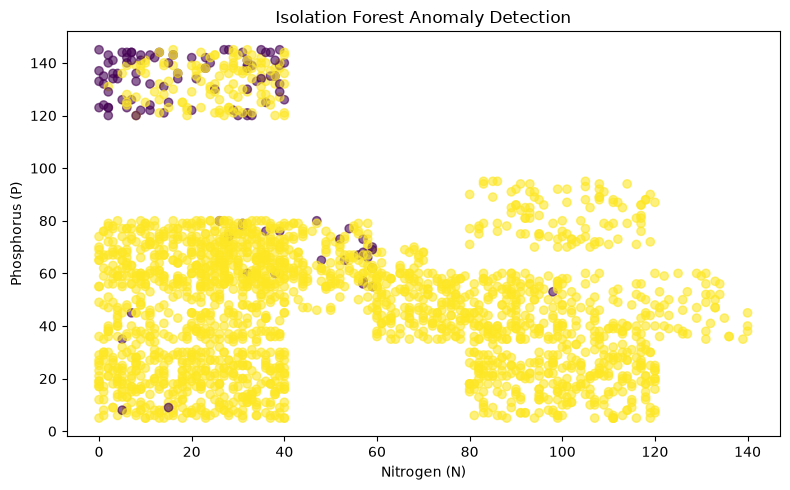

In [63]:
# M4: Isolation Forest Anomaly Detection

from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Create Isolation Forest model
isolation_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Detect anomalies
anomaly_labels = isolation_forest.fit_predict(X)

# Count normal and anomalous records
normal_count = (anomaly_labels == 1).sum()
anomaly_count = (anomaly_labels == -1).sum()

print("Isolation Forest Results")
print("------------------------")
print("Normal records:", normal_count)
print("Anomalous records:", anomaly_count)

# Visualize using N and P
plt.figure(figsize=(8, 5))

plt.scatter(
    X["N"],
    X["P"],
    c=anomaly_labels,
    alpha=0.6
)

plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Nitrogen (N)")
plt.ylabel("Phosphorus (P)")

plt.tight_layout()
plt.show()

# M4. Unsupervised Learning and Anomaly Detection

Although the main crop recommendation task is a supervised multiclass classification problem, unsupervised learning techniques were also explored to analyze the structure of the agricultural data.

### K-Means Clustering
K-Means was applied with different values of K. The Elbow Method and Silhouette Score were used to study the appropriate cluster structure.

### Hierarchical Clustering
Hierarchical clustering using the Ward method was applied to visualize relationships between observations using a dendrogram.

### DBSCAN
DBSCAN was applied to identify density-based groups and potentially noisy observations without requiring a predefined number of clusters.

### Isolation Forest
Isolation Forest was used for anomaly detection. It identifies observations that differ substantially from the majority of the dataset.

### Purpose
These unsupervised techniques are used for exploratory analysis and anomaly detection. They do not replace the supervised crop recommendation model.

PCA completed successfully!
Original number of features: 7
Reduced number of components: 2

Explained variance ratio:
[0.27588831 0.18484431]

Total variance explained by 2 components: 0.4607


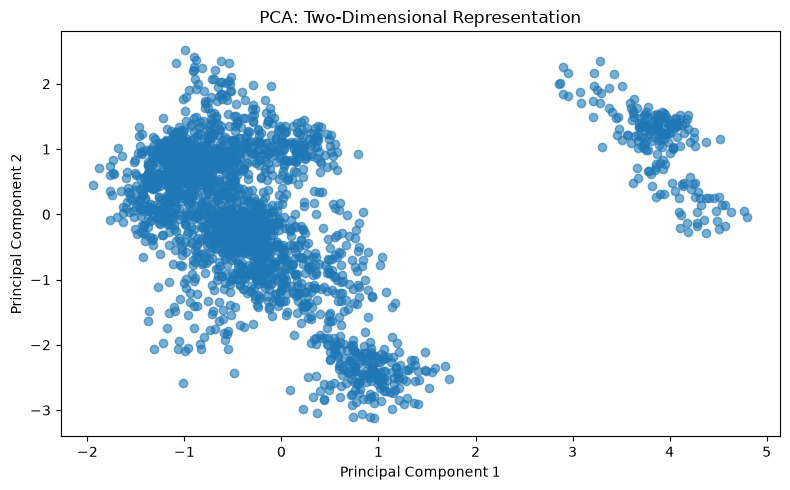

In [64]:
# M4: PCA Dimensionality Reduction

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardize the seven numerical features
pca_scaler = StandardScaler()
X_pca_scaled = pca_scaler.fit_transform(X)

# Reduce 7 features to 2 principal components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_pca_scaled)

print("PCA completed successfully!")
print("Original number of features:", X.shape[1])
print("Reduced number of components:", X_pca.shape[1])

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained by 2 components:",
      round(pca.explained_variance_ratio_.sum(), 4))


# Plot the two principal components
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.6
)

plt.title("PCA: Two-Dimensional Representation")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

# M4. Unsupervised Learning Summary

The following unsupervised learning and anomaly detection techniques were explored:

| Technique | Purpose |
|---|---|
| K-Means | Identify groups of similar agricultural conditions |
| Hierarchical Clustering | Visualize relationships between observations |
| DBSCAN | Identify density-based clusters and noise |
| Isolation Forest | Detect potentially anomalous observations |
| PCA | Reduce the seven-dimensional feature space for visualization |

These techniques support exploratory analysis of the dataset. The final crop recommendation task remains a supervised multiclass classification problem because the dataset contains known crop labels.

In [65]:
# Final Model Comparison Table

final_results_display = final_results.copy()

# Round numerical values for presentation
numeric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

final_results_display[numeric_columns] = (
    final_results_display[numeric_columns].round(4)
)

print("FINAL MODEL COMPARISON")
print("=" * 80)

final_results_display

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9727,0.9740,0.9727,0.9725,0.9998
1,Decision Tree,0.9636,0.9718,0.9636,0.9639,0.9949
2,Random Forest,0.9955,0.9957,0.9955,0.9955,1.0000
3,Gradient Boosting,0.9886,0.9897,0.9886,0.9887,1.0000
4,Tuned Decision Tree,0.9818,0.9830,0.9818,0.9817,0.9905
5,Tuned Random Forest,0.9955,0.9957,0.9955,0.9955,1.0000
6,Tuned Gradient Boosting,0.9932,0.9934,0.9932,0.9932,1.0000
7,Hybrid Voting Classifier,0.9955,0.9957,0.9955,0.9955,1.0000


In [66]:
# Identify the best-performing model

best_model_row = final_results.loc[
    final_results["F1 Score"].idxmax()
]

print("BEST-PERFORMING MODEL")
print("=" * 40)

print("Model:", best_model_row["Model"])
print("Accuracy:", round(best_model_row["Accuracy"], 4))
print("Precision:", round(best_model_row["Precision"], 4))
print("Recall:", round(best_model_row["Recall"], 4))
print("F1 Score:", round(best_model_row["F1 Score"], 4))
print("ROC-AUC:", round(best_model_row["ROC-AUC"], 4))

BEST-PERFORMING MODEL
Model: Random Forest
Accuracy: 0.9955
Precision: 0.9957
Recall: 0.9955
F1 Score: 0.9955
ROC-AUC: 1.0


In [67]:
# Select the best-performing model for final deployment

final_model = random_forest_model

print("Final deployment model selected:")
print("Random Forest")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf, average="weighted"), 4))
print("ROC-AUC:", round(
    roc_auc_score(
        y_test,
        y_prob_rf,
        multi_class="ovr",
        average="weighted"
    ), 4
))

Final deployment model selected:
Random Forest
Accuracy: 0.9955
F1 Score: 0.9955
ROC-AUC: 1.0


In [71]:
# Save the final Random Forest model package

final_model_package = {
    "model": final_model,
    "label_encoder": label_encoder,
    "features": [
        "N",
        "P",
        "K",
        "temperature",
        "humidity",
        "ph",
        "rainfall"
    ]
}

joblib.dump(
    final_model_package,
    "final_crop_recommendation_model.pkl"
)

print("Final model package saved successfully!")
print("Model: Random Forest")
print("File: final_crop_recommendation_model.pkl")

Final model package saved successfully!
Model: Random Forest
File: final_crop_recommendation_model.pkl
